# ColoredMNIST Dataset Overview

This notebook explains the generated ColoredMNIST dataset used for the toy split-SAE experiment.

The important idea is that digit shape is the semantic signal, while digit color is the domain/confounder signal. The split-SAE will later try to learn a `z_good` representation that keeps digit information while removing color information, and a `z_bad` representation that captures color/domain information.

## Generated Files

The dataset generator creates seven files:

- `ae_train_balanced.npz`: train split for the base autoencoder, with balanced colors.
- `ae_val_balanced.npz`: validation split for the base autoencoder, with balanced colors.
- `split_train_biased.npz`: train split for the split-SAE, with the shortcut color bias.
- `split_val_biased.npz`: validation split for the split-SAE, with the same shortcut color bias.
- `test_id_biased.npz`: in-distribution test split, matching the train color bias.
- `test_balanced.npz`: test split where color is independent of digit identity.
- `test_reversed.npz`: stress-test split where the train color shortcut is reversed.

The final test files come from the original MNIST test set. The train and validation files come from a stratified split of the original MNIST training set.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / "data" / "colored_mnist").exists():
    project_root = project_root.parent

data_dir = project_root / "data" / "colored_mnist"
print(data_dir)
assert data_dir.exists(), "Run scripts/generate_colored_mnist.py before this notebook."

/Users/cuzdu/Desktop/toy-sae/data/colored_mnist


In [2]:
split_info = [
    ("ae_train_balanced", "MNIST train partition", "Base AE training", "Balanced red/green"),
    ("ae_val_balanced", "MNIST validation partition", "Base AE validation", "Balanced red/green"),
    ("split_train_biased", "MNIST train partition", "Split-SAE training", "0-4 mostly green, 5-9 mostly red"),
    ("split_val_biased", "MNIST validation partition", "Split-SAE validation", "0-4 mostly green, 5-9 mostly red"),
    ("test_id_biased", "MNIST test split", "In-distribution test", "0-4 mostly green, 5-9 mostly red"),
    ("test_balanced", "MNIST test split", "Balanced color-shift test", "Balanced red/green"),
    ("test_reversed", "MNIST test split", "Reversed shortcut test", "0-4 mostly red, 5-9 mostly green"),
]

def load_small_arrays(split_name):
    path = data_dir / f"{split_name}.npz"
    data = np.load(path)
    digits = data["digits"]
    colors = data["colors"]
    metadata = json.loads(str(data["metadata"]))
    data.close()
    return digits, colors, metadata

def split_summary(split_name):
    digits, colors, metadata = load_small_arrays(split_name)
    lower = digits < 5
    upper = digits >= 5
    return {
        "examples": len(digits),
        "red": int((colors == 0).sum()),
        "green": int((colors == 1).sum()),
        "green_rate_all": colors.mean(),
        "green_rate_0_4": colors[lower].mean(),
        "green_rate_5_9": colors[upper].mean(),
        "scheme": metadata["scheme"],
    }

summaries = {name: split_summary(name) for name, _, _, _ in split_info}

rows = [
    "| file | source | purpose | color rule | n | green rate 0-4 | green rate 5-9 |",
    "|---|---|---|---|---:|---:|---:|",
]
for name, source, purpose, rule in split_info:
    summary = summaries[name]
    rows.append(
        f"| `{name}.npz` | {source} | {purpose} | {rule} | "
        f"{summary['examples']} | {summary['green_rate_0_4']:.3f} | {summary['green_rate_5_9']:.3f} |"
    )

display(Markdown("\n".join(rows)))

| file | source | purpose | color rule | n | green rate 0-4 | green rate 5-9 |
|---|---|---|---|---:|---:|---:|
| `ae_train_balanced.npz` | MNIST train partition | Base AE training | Balanced red/green | 50000 | 0.504 | 0.498 |
| `ae_val_balanced.npz` | MNIST validation partition | Base AE validation | Balanced red/green | 10000 | 0.504 | 0.515 |
| `split_train_biased.npz` | MNIST train partition | Split-SAE training | 0-4 mostly green, 5-9 mostly red | 50000 | 0.900 | 0.099 |
| `split_val_biased.npz` | MNIST validation partition | Split-SAE validation | 0-4 mostly green, 5-9 mostly red | 10000 | 0.902 | 0.097 |
| `test_id_biased.npz` | MNIST test split | In-distribution test | 0-4 mostly green, 5-9 mostly red | 10000 | 0.903 | 0.099 |
| `test_balanced.npz` | MNIST test split | Balanced color-shift test | Balanced red/green | 10000 | 0.493 | 0.497 |
| `test_reversed.npz` | MNIST test split | Reversed shortcut test | 0-4 mostly red, 5-9 mostly green | 10000 | 0.099 | 0.901 |

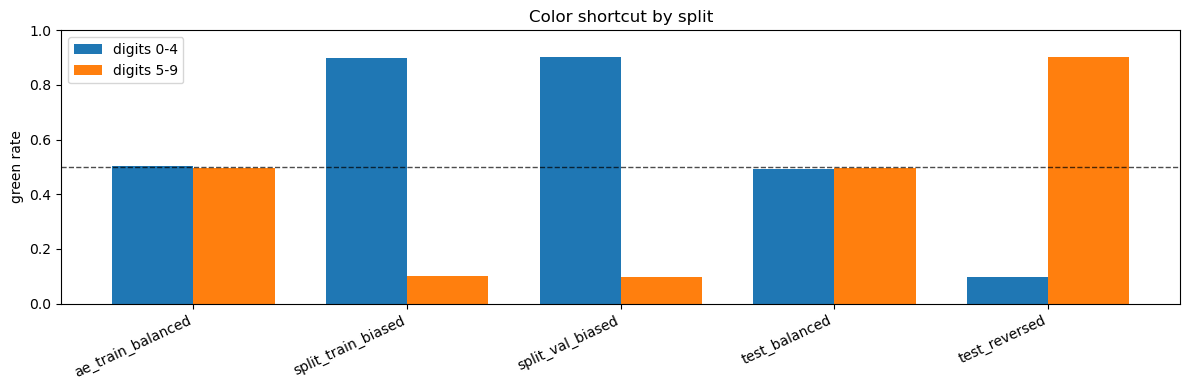

In [3]:
plot_splits = [
    "ae_train_balanced",
    "split_train_biased",
    "split_val_biased",
    "test_balanced",
    "test_reversed",
]

x = np.arange(len(plot_splits))
green_0_4 = [summaries[name]["green_rate_0_4"] for name in plot_splits]
green_5_9 = [summaries[name]["green_rate_5_9"] for name in plot_splits]

fig, ax = plt.subplots(figsize=(12, 4))
width = 0.38
ax.bar(x - width / 2, green_0_4, width, label="digits 0-4")
ax.bar(x + width / 2, green_5_9, width, label="digits 5-9")
ax.axhline(0.5, color="black", linewidth=1, linestyle="--", alpha=0.7)
ax.set_ylim(0, 1)
ax.set_ylabel("green rate")
ax.set_xticks(x)
ax.set_xticklabels(plot_splits, rotation=25, ha="right")
ax.set_title("Color shortcut by split")
ax.legend()
plt.tight_layout()

In [4]:
color_names = {0: "red", 1: "green"}

def image_to_plot(image):
    return np.moveaxis(image, 0, -1)

def choose_index(digits, colors, digit, preferred_color):
    matching = np.flatnonzero((digits == digit) & (colors == preferred_color))
    if len(matching) == 0:
        matching = np.flatnonzero(digits == digit)
    return matching[0]

def show_digit_row(split_name, preferred_colors, title):
    path = data_dir / f"{split_name}.npz"
    data = np.load(path)
    images = data["images"]
    digits = data["digits"]
    colors = data["colors"]

    fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))
    for digit, ax in enumerate(axes):
        idx = choose_index(digits, colors, digit, preferred_colors[digit])
        ax.imshow(image_to_plot(images[idx]))
        ax.set_title(f"{digit}\n{color_names[int(colors[idx])]}")
        ax.axis("off")

    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    data.close()

biased_colors = {digit: 1 if digit < 5 else 0 for digit in range(10)}
reversed_colors = {digit: 0 if digit < 5 else 1 for digit in range(10)}

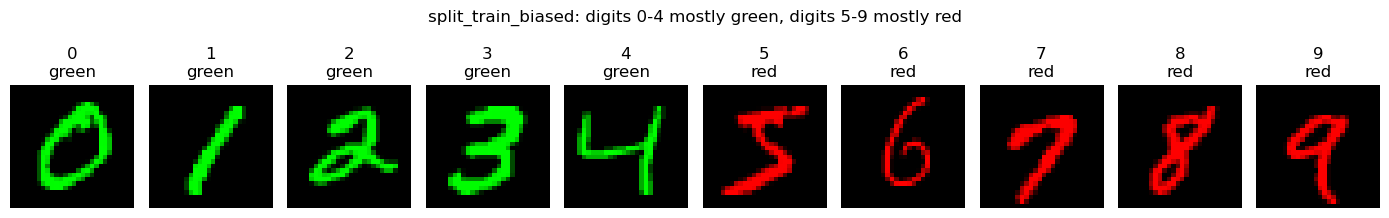

In [5]:
show_digit_row(
    "split_train_biased",
    biased_colors,
    "split_train_biased: digits 0-4 mostly green, digits 5-9 mostly red",
)

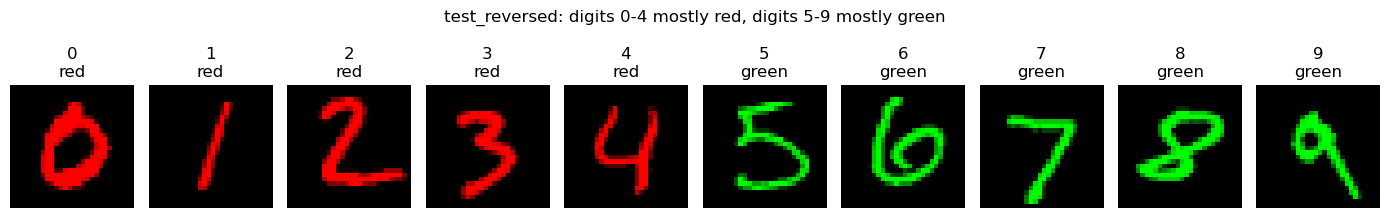

In [6]:
show_digit_row(
    "test_reversed",
    reversed_colors,
    "test_reversed: digits 0-4 mostly red, digits 5-9 mostly green",
)

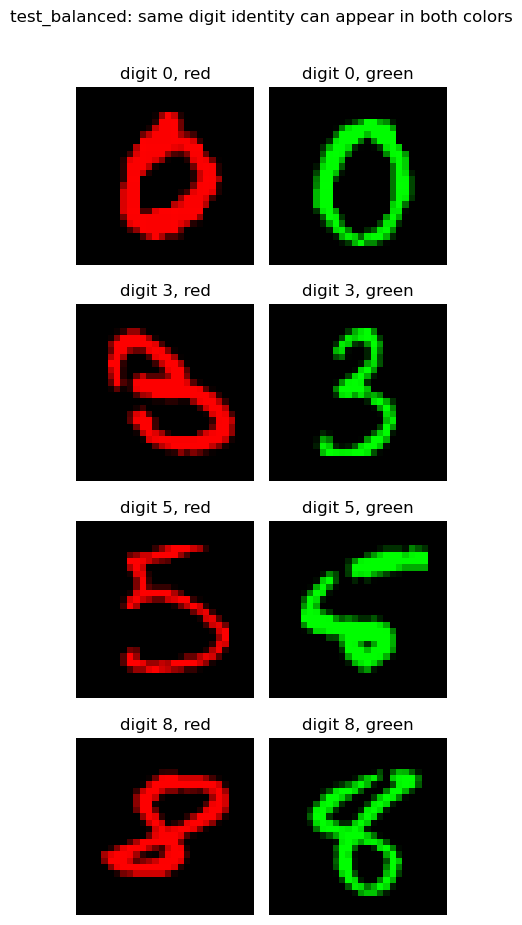

In [7]:
def show_color_pairs(split_name, digits_to_show):
    path = data_dir / f"{split_name}.npz"
    data = np.load(path)
    images = data["images"]
    digits = data["digits"]
    colors = data["colors"]

    fig, axes = plt.subplots(len(digits_to_show), 2, figsize=(4, 2.3 * len(digits_to_show)))
    for row, digit in enumerate(digits_to_show):
        for color in [0, 1]:
            idx = choose_index(digits, colors, digit, color)
            ax = axes[row, color]
            ax.imshow(image_to_plot(images[idx]))
            ax.set_title(f"digit {digit}, {color_names[color]}")
            ax.axis("off")

    fig.suptitle(f"{split_name}: same digit identity can appear in both colors", y=1.01)
    plt.tight_layout()
    data.close()

show_color_pairs("test_balanced", [0, 3, 5, 8])